# **Exploratory Data Analysis**

## **1. Data Cleaning & Processing**

### 1.1. Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   -- ------------------------------------ 20.5/306.1 kB 162.5 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/306.1 kB 326.8 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/306.1 kB 435.7 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/306.1 kB 435.7 kB/s eta 0:00:01
   ------------------------- ------------ 204.8/306.1 kB 778.2 kB/s eta 0:00:01
   ------------------------- ------------ 204.8/306.1 kB 778.2 kB/s eta 0:00:01
   --------------------------- ---------- 225.3/306.1 kB 655.6 kB/s eta 0:00:01
   ----------------------------- -------- 235.5/306.1 kB 600.7 kB/s eta 0:00:01
   --

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from collections import Counter
import textwrap
import warnings
import re
import string

warnings.filterwarnings('ignore')
%matplotlib inline

#### ***Style Configuration***

In [3]:
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (13, 6),
    'font.size': 12,
    'font.family': 'serif',
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 100,
})

#### ***Color Palette***

In [4]:
DARK      = '#1a1a2e'
GOLD      = '#f5a623'
GREEN     = '#27ae60'
SILVER    = '#b0bec5'
NAVY      = '#3b6cb5'
CRIMSON   = '#e94560'
TEAL      = '#2a9d8f'
RED       = '#ff0000'
SUNFLOWER = '#ffda03'
PALETTE = [DARK,NAVY, CRIMSON, TEAL, GOLD, GREEN, SILVER, RED,SUNFLOWER]
print("style configured successfully. with color palette")

style configured successfully. with color palette


### 1.2. Data Loading & Preview

#### ***Load the dataset and configure***

In [5]:
df = pd.read_csv('dataset/amazon_product_reviews.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 568,454 rows × 10 columns


#### ***View first 5 rows***

In [6]:
df.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have foun...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually ...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, p..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have ...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. ...


#### ***View column-wise data types and used-memory***

In [7]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 445.8 MB


#### ***View numeric summary***

In [8]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [9]:
df.describe(include='object')

,ProductId,UserId,ProfileName,Summary,Text
count,568454,568454,568428,568427,568454
unique,74258,256059,218415,295742,393579
top,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",Delicious!,"This review will make me sound really stupid, but whatever. I don't really c..."
freq,913,448,451,2462,199


#### ***Check quantity of missing values***

In [10]:
missing_summary = pd.DataFrame({
    'Count Missing': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(4)
})
missing_summary

,Count Missing,Missing %
Id,0,0.0000
ProductId,0,0.0000
UserId,0,0.0000
ProfileName,26,0.0046
HelpfulnessNumerator,0,0.0000
HelpfulnessDenominator,0,0.0000
Score,0,0.0000
Time,0,0.0000
Summary,27,0.0047
Text,0,0.0000


### 1.3. Data Quality Evaluation 

#### ***Score Range Validation***

In [11]:
print("Score value counts:")
print(df['Score'].value_counts().sort_index())
invalid_scores = df[(df['Score'] < 1) | (df['Score'] > 5)]
print(f"Invalid scores (outside 1-5): {len(invalid_scores)}")

Score value counts:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64
Invalid scores (outside 1-5): 0


#### ***Helpfulness Data Integrity***

In [12]:
invalid_helpful = df[df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']]
print(f"Total reviews: {len(df):,}")
print(f"Invalid helpfulness (Numerator > Denominator): {len(invalid_helpful):,} ({len(invalid_helpful)/len(df)*100:.3f}%)")
print(f"Reviews with zero helpfulness votes: {(df['HelpfulnessDenominator'] == 0).sum():,} ({(df['HelpfulnessDenominator'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Reviews with at least one helpfulness vote: {(df['HelpfulnessDenominator'] > 0).sum():,}")

Total reviews: 568,454
Invalid helpfulness (Numerator > Denominator): 2 (0.000%)
Reviews with zero helpfulness votes: 270,052 (47.5%)
Reviews with at least one helpfulness vote: 298,402


#### ***Check Duplicates***

In [13]:
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate (UserId + ProductId): {df.duplicated(subset=['UserId', 'ProductId']).sum():,}")
print(f"Duplicate (UserId + ProductId + Score): {df.duplicated(subset=['UserId', 'ProductId', 'Score']).sum():,}")
print(f"Duplicate (UserId + ProductId + Text): {df.duplicated(subset=['UserId', 'ProductId', 'Text']).sum():,}")

Exact duplicate rows: 0
Duplicate (UserId + ProductId): 7,650
Duplicate (UserId + ProductId + Score): 5,824
Duplicate (UserId + ProductId + Text): 1,309


#### ***Visualize Missing Value***

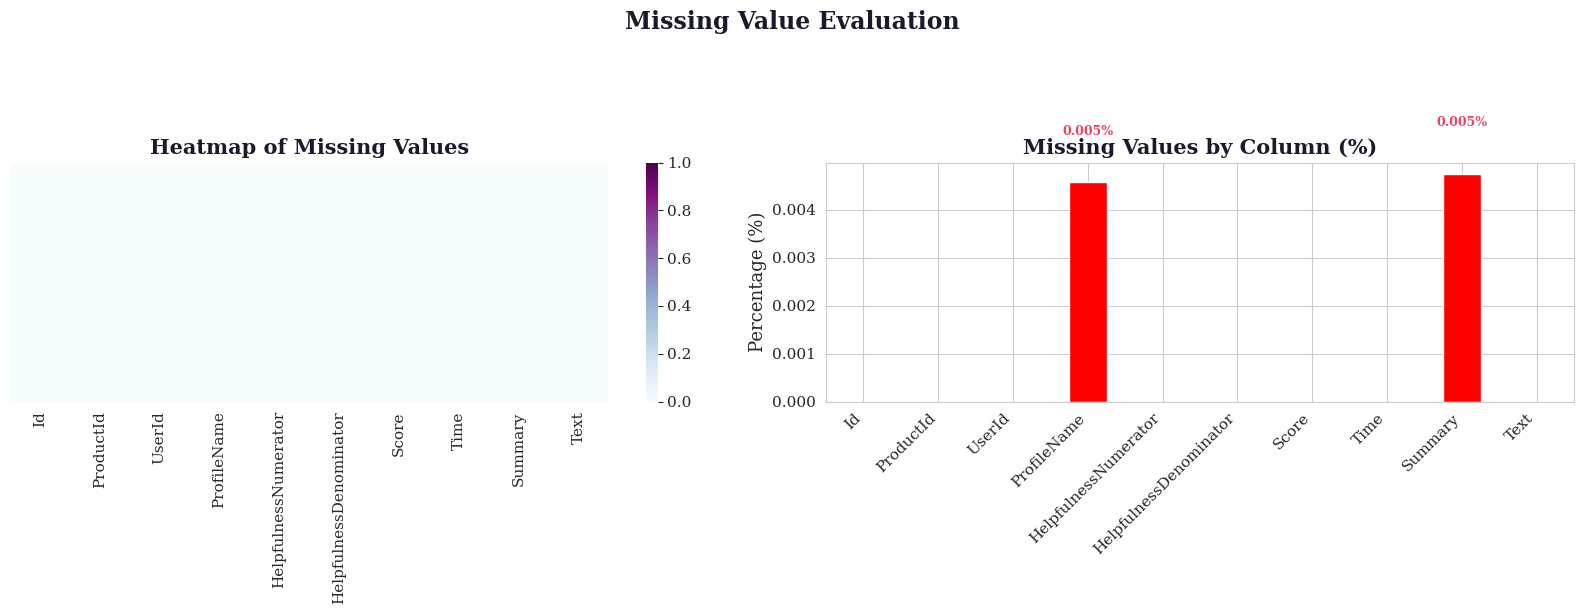

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='BuPu', ax=axes[0])
axes[0].set_title('Heatmap of Missing Values', fontsize=15, color=DARK, fontweight='bold')
axes[0].set_xlabel('')

missing_pct = df.isnull().sum() / len(df) * 100
colors = [RED if x > 0 else SILVER for x in missing_pct]
missing_pct.plot(kind='bar', color=colors, edgecolor='white', ax=axes[1])
axes[1].set_title('Missing Values by Column (%)', fontsize=15, color=DARK, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
for i, v in enumerate(missing_pct):
    if v > 0:
        axes[1].text(i, v + 0.001, f'{v:.3f}%', ha='center', fontsize=9, color=CRIMSON, fontweight='bold')
plt.suptitle('Missing Value Evaluation', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.4. Data Cleaning & Validation

#### ***Fix Invalid Helpfulness***

In [15]:
invalid_count_before = (df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']).sum()
df['HelpfulnessNumerator'] = df[['HelpfulnessNumerator', 'HelpfulnessDenominator']].min(axis=1)
invalid_count_after = (df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']).sum()
print(f"Current Invalid helpfulness: {invalid_count_after}")

Current Invalid helpfulness: 0


#### ***Handling Missing Value***

In [16]:
df['ProfileName'] = df['ProfileName'].fillna('Nameless')
df['Summary'] = df['Summary'].fillna('No Summary')
print("Missing values after cleaning:")
print(df[['ProfileName', 'Summary']].isnull().sum())

Missing values after cleaning:
ProfileName    0
Summary        0
dtype: int64


#### ***De-duplication for Exact Rows***

In [17]:
initial_count = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed Duplicated Rows: {initial_count - len(df)} ")

Removed Duplicated Rows: 0 


#### ***Convert Timestamp to Datetime***

In [18]:
df['DateTime'] = pd.to_datetime(df['Time'], unit='s')
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Month_Name'] = df['DateTime'].dt.month_name()
df['Day_Of_Week'] = df['DateTime'].dt.day_name()
df['Quarter'] = df['DateTime'].dt.quarter
print("Created Temporal Columns:")
print(df[['Time', 'DateTime', 'Year', 'Month', 'Month_Name', 'Day_Of_Week', 'Quarter']].head(5))
print(f"\nDate range: {df['DateTime'].min().strftime('%B %d, %Y')} — {df['DateTime'].max().strftime('%B %d, %Y')}")

Created Temporal Columns:
         Time   DateTime  Year  Month Month_Name Day_Of_Week  Quarter
0  1303862400 2011-04-27  2011      4      April   Wednesday        2
1  1346976000 2012-09-07  2012      9  September      Friday        3
2  1219017600 2008-08-18  2008      8     August      Monday        3
3  1307923200 2011-06-13  2011      6       June      Monday        2
4  1350777600 2012-10-21  2012     10    October      Sunday        4

Date range: October 08, 1999 — October 26, 2012


## 1.5. Feature Engineering

In [19]:
df['HelpfulnessRatio'] = np.where(
    df['HelpfulnessDenominator'] > 0,
    df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'],
    np.nan
)
df['IsHelpful'] = ((df['HelpfulnessRatio'] > 0.5) & (df['HelpfulnessDenominator'] >= 5)).astype(int)
df['HasVotes'] = (df['HelpfulnessDenominator'] > 0).astype(int)

df['ReviewLength'] = df['Text'].astype(str).str.len()
df['SummaryLength'] = df['Summary'].astype(str).str.len()
df['WordCount'] = df['Text'].astype(str).str.split().str.len()
df['SentenceCount'] = df['Text'].astype(str).str.count(r'[.!?]+')
df['AvgWordLength'] = df['Text'].astype(str).apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0).round(2)
def categorize_score(score):
    if score >= 4:
        return 'Positive (4-5)'
    elif score == 3:
        return 'Neutral (3)'
    else:
        return 'Negative (1-2)'
df['ScoreCategory'] = df['Score'].apply(categorize_score)
max_date = df['DateTime'].max()
df['ReviewAgeDays'] = (max_date - df['DateTime']).dt.days
print("Engineered features summary:")
print(df[['HelpfulnessRatio', 'IsHelpful', 'HasVotes', 'ReviewLength', 'WordCount',
          'SentenceCount', 'AvgWordLength', 'ScoreCategory', 'ReviewAgeDays']].describe().round(2))

Engineered features summary:
       HelpfulnessRatio  IsHelpful   HasVotes  ReviewLength  WordCount  \
count         298402.00  568454.00  568454.00     568454.00  568454.00   
mean               0.78       0.09       0.52        436.22      80.26   
std                0.35       0.29       0.50        445.34      79.46   
min                0.00       0.00       0.00         12.00       3.00   
25%                0.60       0.00       0.00        179.00      33.00   
50%                1.00       0.00       1.00        302.00      56.00   
75%                1.00       0.00       1.00        527.00      98.00   
max                1.00       1.00       1.00      21409.00    3432.00   

       SentenceCount  AvgWordLength  ReviewAgeDays  
count      568454.00      568454.00      568454.00  
mean            5.78           4.40         636.03  
std             4.95           0.44         556.06  
min             0.00           1.00           0.00  
25%             3.00           4.12    

In [20]:
df.head(5)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,DateTime,Year,Month,Month_Name,Day_Of_Week,Quarter,HelpfulnessRatio,IsHelpful,HasVotes,ReviewLength,SummaryLength,WordCount,SentenceCount,AvgWordLength,ScoreCategory,ReviewAgeDays
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have foun...,2011-04-27,2011,4,April,Wednesday,2,1.0,0,1,263,21,48,3,4.48,Positive (4-5),548
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually ...,2012-09-07,2012,9,September,Friday,3,NaN,0,0,190,17,31,3,5.16,Negative (1-2),49
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, p...",2008-08-18,2008,8,August,Monday,3,1.0,0,1,509,21,94,9,4.37,Positive (4-5),1530
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have ...,2011-06-13,2011,6,June,Monday,2,1.0,0,1,219,14,41,3,4.32,Negative (1-2),501
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. ...,2012-10-21,2012,10,October,Sunday,4,NaN,0,0,140,11,27,4,4.11,Positive (4-5),5


#### ***Key Metrics Summary***

In [21]:
numeric_cols = ['HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score',
                'ReviewLength', 'WordCount', 'SentenceCount', 'AvgWordLength',
                'HelpfulnessRatio', 'ReviewAgeDays']
stats = df[numeric_cols].describe().T
stats['skewness'] = df[numeric_cols].skew()
stats['kurtosis'] = df[numeric_cols].kurtosis()
stats['IQR'] = stats['75%'] - stats['25%']
stats.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR
HelpfulnessNumerator,568454.0,1.744,7.637,0.0,0.00,0.00,2.00,866.0,37.522,2410.645,2.0
HelpfulnessDenominator,568454.0,2.229,8.290,0.0,0.00,1.00,2.00,923.0,32.633,1949.719,2.0
Score,568454.0,4.183,1.310,1.0,4.00,5.00,5.00,5.0,-1.461,0.751,1.0
ReviewLength,568454.0,436.222,445.340,12.0,179.00,302.00,527.00,21409.0,5.064,70.423,348.0
WordCount,568454.0,80.264,79.455,3.0,33.00,56.00,98.00,3432.0,4.670,55.322,65.0
SentenceCount,568454.0,5.776,4.951,0.0,3.00,4.00,7.00,385.0,5.056,103.154,4.0
AvgWordLength,568454.0,4.401,0.441,1.0,4.12,4.36,4.62,35.3,1.923,49.651,0.5
HelpfulnessRatio,298402.0,0.777,0.346,0.0,0.60,1.00,1.00,1.0,-1.329,0.287,0.4
ReviewAgeDays,568454.0,636.030,556.057,0.0,214.00,464.00,925.00,4767.0,1.228,1.225,711.0


## ***2. Data Visualization***

## 2.1. Outlier Detection

#### ***Numeric Feature Outlier Boxplots***

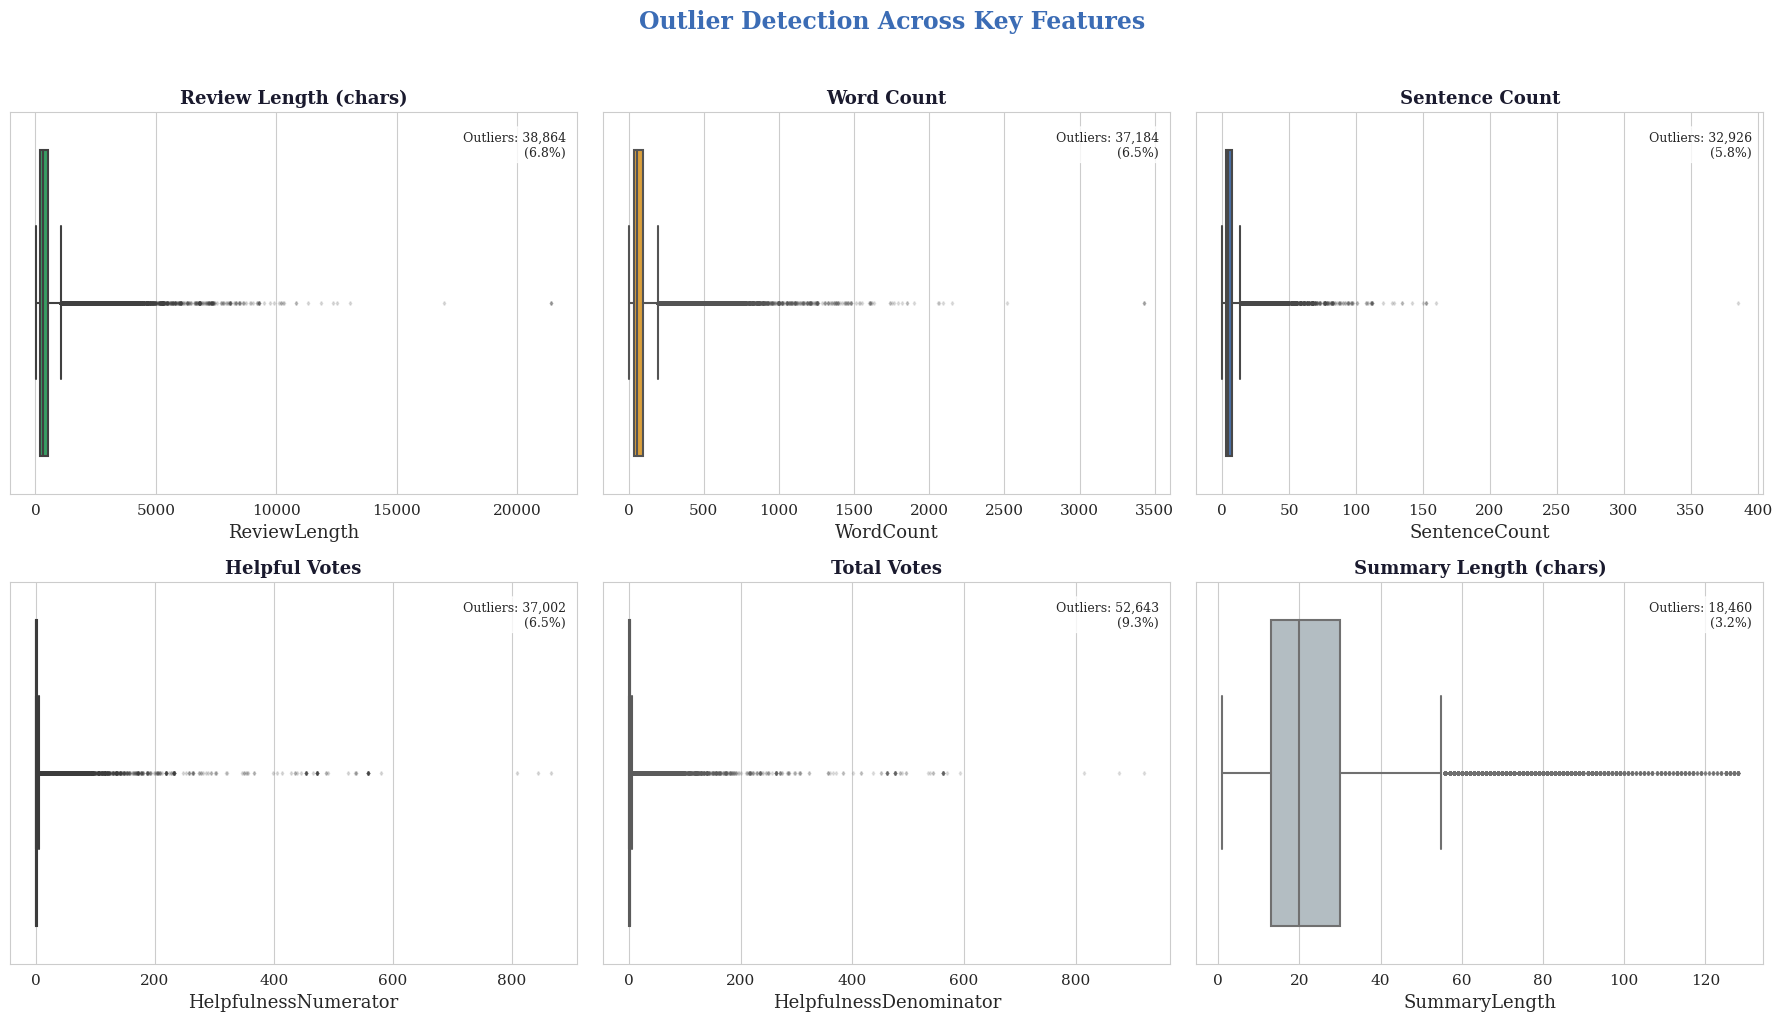

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
outlier_features = [
    ('ReviewLength', 'Review Length (chars)', GREEN),
    ('WordCount', 'Word Count', GOLD),
    ('SentenceCount', 'Sentence Count', NAVY),
    ('HelpfulnessNumerator', 'Helpful Votes', TEAL),
    ('HelpfulnessDenominator', 'Total Votes', CRIMSON),
    ('SummaryLength', 'Summary Length (chars)', SILVER),
]
for ax, (col, label, color) in zip(axes.flat, outlier_features):
    sns.boxplot(x=df[col], color=color, ax=ax, flierprops={'alpha': 0.15, 'markersize': 2})
    ax.set_title(label, fontsize=13, color=DARK, fontweight='bold')
    
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    ax.text(0.98, 0.95, f'Outliers: {outliers:,}\n({outliers/len(df)*100:.1f}%)',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.suptitle('Outlier Detection Across Key Features',
             fontsize=17, color=NAVY, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.2. Univariate Analysis

#### ***Star Rating Distribution***

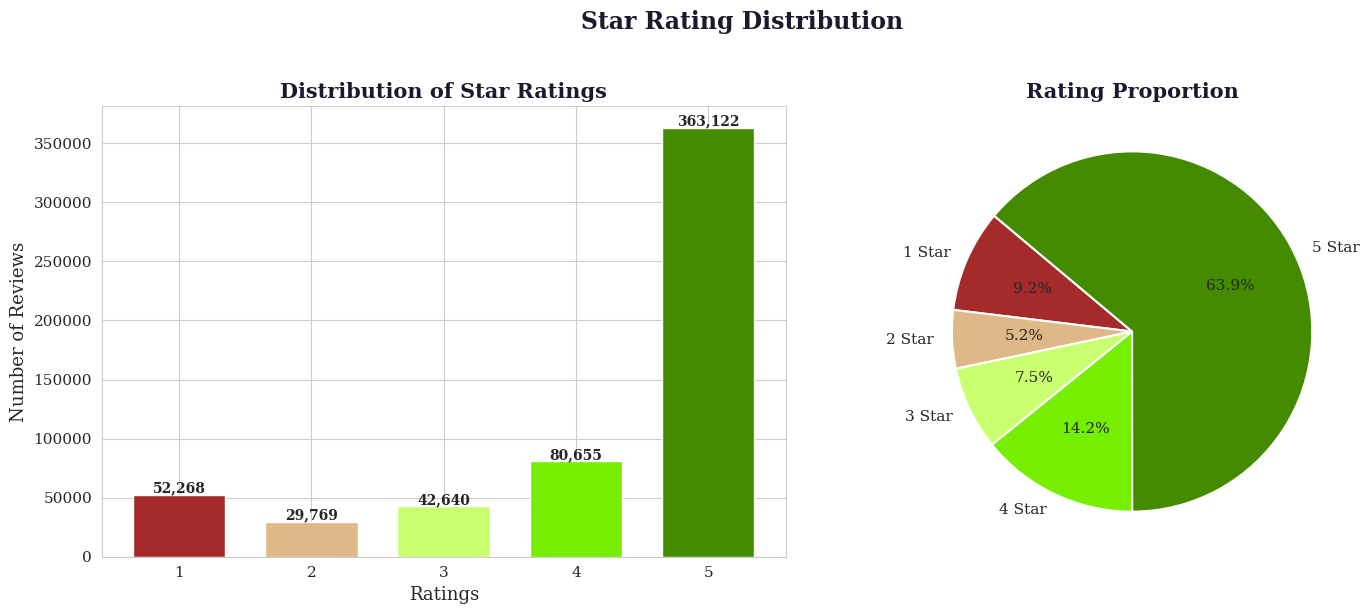

Skewness: -1.461
Kurtosis: 0.751


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
score_counts = df['Score'].value_counts().sort_index()
colors_score =  ['#a52a2a', '#deb887', '#caff70', '#76ee00', '#458b00']

bars = axes[0].bar(score_counts.index, score_counts.values, color=colors_score, edgecolor='white', width=0.7)
axes[0].set_title('Distribution of Star Ratings', fontsize=15, color=DARK, fontweight='bold')
axes[0].set_xlabel('Ratings')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])
for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

axes[1].pie(score_counts.values, labels=[f'{s} Star' for s in score_counts.index],
            colors=colors_score, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 11})
axes[1].set_title('Rating Proportion', fontsize=15, color=DARK, fontweight='bold')

plt.suptitle('Star Rating Distribution', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"Skewness: {df['Score'].skew():.3f}")
print(f"Kurtosis: {df['Score'].kurtosis():.3f}")

#### ***Sentiment Class Distribution***

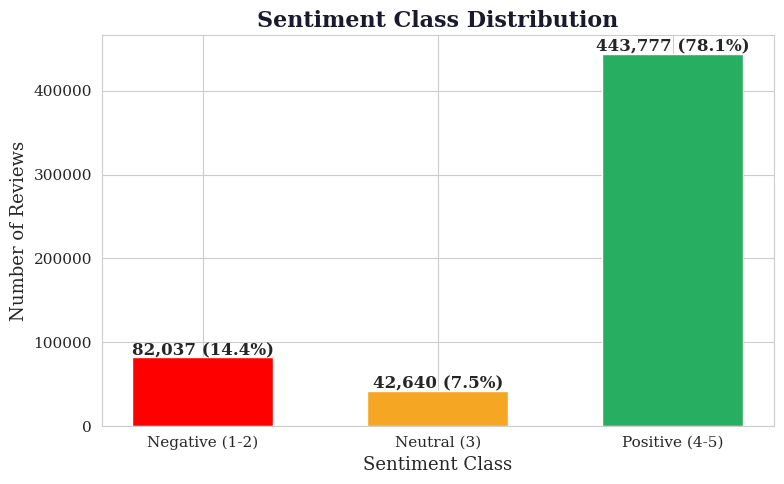

In [24]:
fig, ax = plt.subplots(figsize=(8, 5),layout='constrained')
class_order = ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)']
class_colors = [RED, GOLD, GREEN]
class_counts = df['ScoreCategory'].value_counts().reindex(class_order)
bars = ax.bar(class_order, class_counts.values, color=class_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'{val:,} ({val/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Sentiment Class Distribution', fontsize=16, color=DARK, fontweight='bold')
ax.set_ylabel('Number of Reviews')
ax.set_xlabel('Sentiment Class')
plt.tight_layout()
plt.show()

#### ***Word Count Distribution***

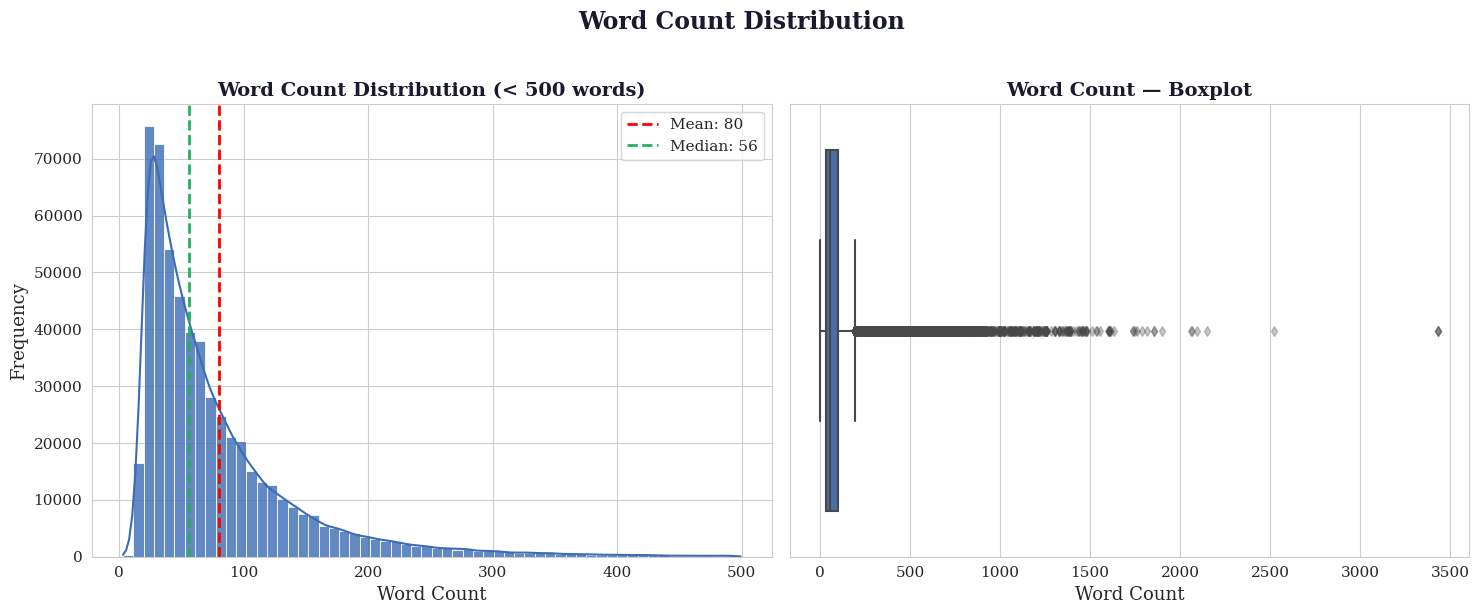

Mean: 80 | Median: 56 | Std: 79
Skewness: 4.670 | Kurtosis: 55.322


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(df['WordCount'][df['WordCount'] < 500], kde=True, bins=60,
             color=NAVY, edgecolor='white', alpha=0.8, ax=axes[0])
axes[0].axvline(df['WordCount'].mean(), color=RED, linestyle='--', linewidth=2,
                label=f"Mean: {df['WordCount'].mean():.0f}")
axes[0].axvline(df['WordCount'].median(), color=GREEN, linestyle='--', linewidth=2,
                label=f"Median: {df['WordCount'].median():.0f}")
axes[0].set_title('Word Count Distribution (< 500 words)', fontsize=14, color=DARK, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(x=df['WordCount'], color=NAVY, ax=axes[1], flierprops={'alpha': 0.3})
axes[1].set_title('Word Count — Boxplot', fontsize=14, color=DARK, fontweight='bold')
axes[1].set_xlabel('Word Count')
plt.suptitle('Word Count Distribution', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"Mean: {df['WordCount'].mean():.0f} | Median: {df['WordCount'].median():.0f} | Std: {df['WordCount'].std():.0f}")
print(f"Skewness: {df['WordCount'].skew():.3f} | Kurtosis: {df['WordCount'].kurtosis():.3f}")

#### ***Review Summary Length Distribution***

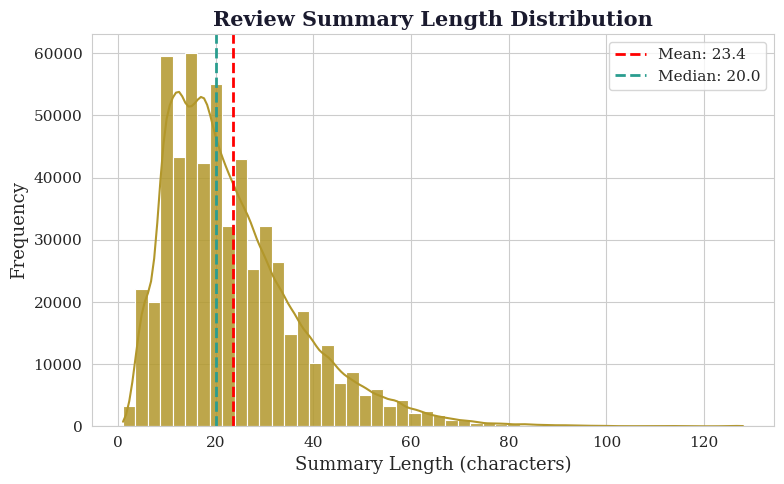

In [26]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
sns.histplot(df['SummaryLength'], bins=50, kde=True, color='#b2972b', edgecolor='white', alpha=0.85, ax=ax)
ax.axvline(df['SummaryLength'].mean(), color=RED, linestyle='--', linewidth=2,
           label=f"Mean: {df['SummaryLength'].mean():.1f}")
ax.axvline(df['SummaryLength'].median(), color=TEAL, linestyle='--', linewidth=2,
           label=f"Median: {df['SummaryLength'].median():.1f}")
ax.set_title('Review Summary Length Distribution', fontsize=15, color=DARK, fontweight='bold')
ax.set_xlabel('Summary Length (characters)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 2.3. Temporal (Time-Series) Analysis

#### ***Review by Year***

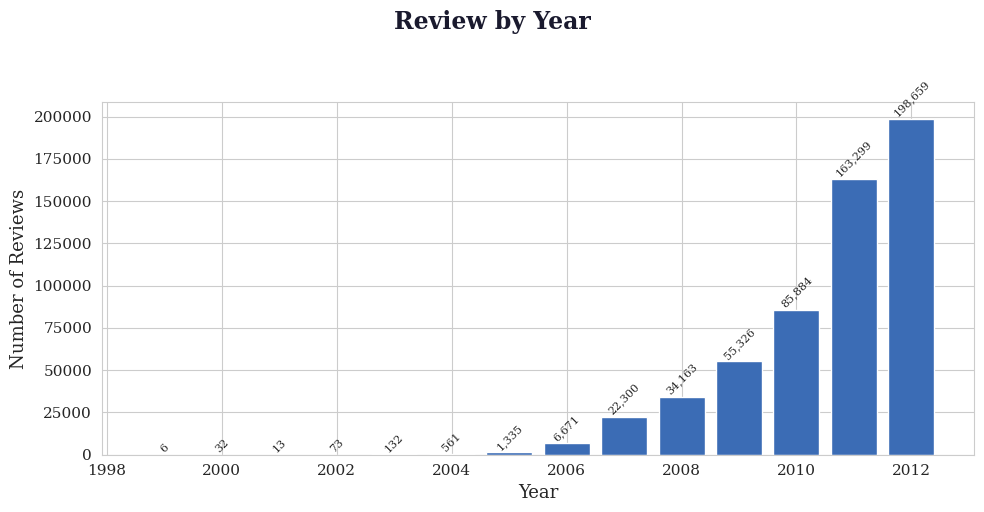

In [27]:
fig, axes = plt.subplots(figsize=(10, 5),layout="constrained")
yearly = df.groupby('Year').size().reset_index(name='Count')

axes.bar(yearly['Year'], yearly['Count'], color=NAVY, edgecolor='white')
axes.set_xlabel('Year')
axes.set_ylabel('Number of Reviews')
axes.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for _, row in yearly.iterrows():
    axes.text(row['Year'], row['Count'] + 1500, f"{row['Count']:,}",
                ha='center', fontsize=8, rotation=45)

plt.suptitle('Review by Year', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### ***Rating Distribution by Year***

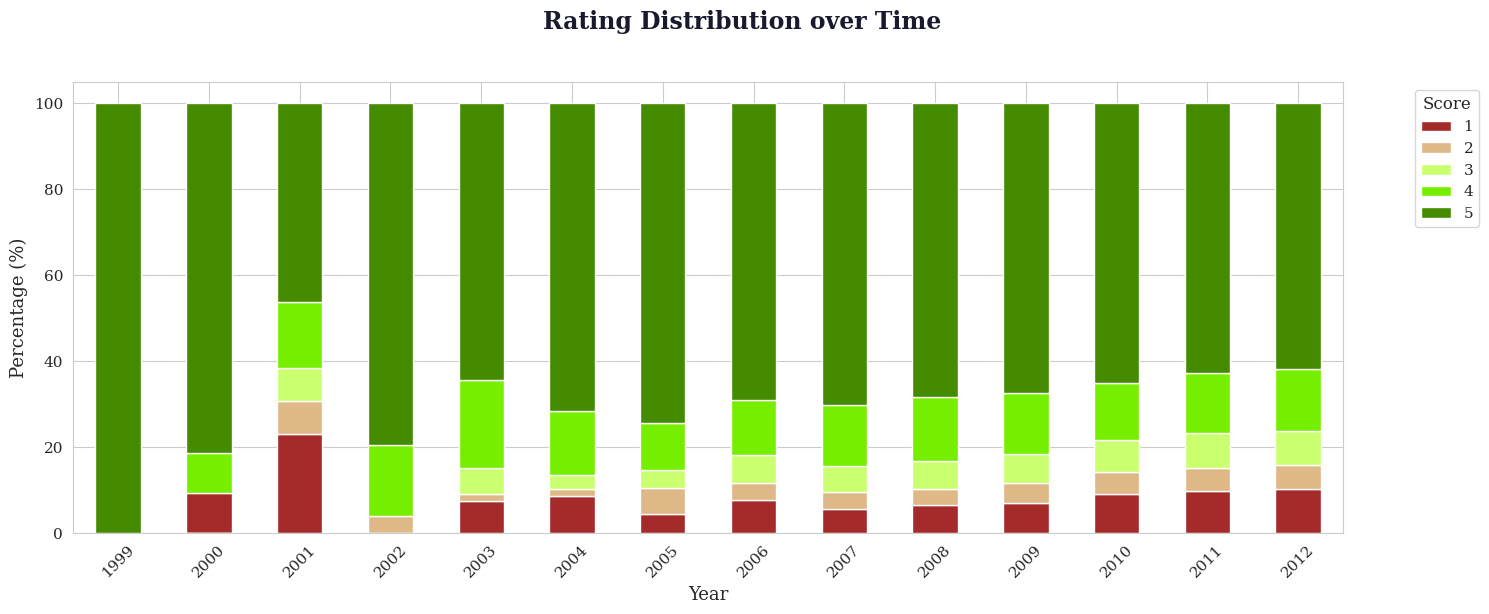

In [28]:
fig, axes = plt.subplots(figsize=(15, 6),layout="constrained")
yearly_score = df.groupby('Year').agg(
    avg_score=('Score', 'mean'),
    count=('Score', 'count')
).reset_index()

score_year = df.groupby(['Year', 'Score']).size().unstack(fill_value=0)
score_year_pct = score_year.div(score_year.sum(axis=1), axis=0) * 100
score_year_pct.plot(kind='bar', stacked=True, color=colors_score, edgecolor='white', ax=axes)
axes.set_xlabel('Year')
axes.set_ylabel('Percentage (%)')
axes.legend(title='Score', bbox_to_anchor=(1.05, 1), loc='upper left')
axes.set_xticklabels(axes.get_xticklabels(), rotation=45)

plt.suptitle('Rating Distribution over Time', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### ***Monthwise Total Review***

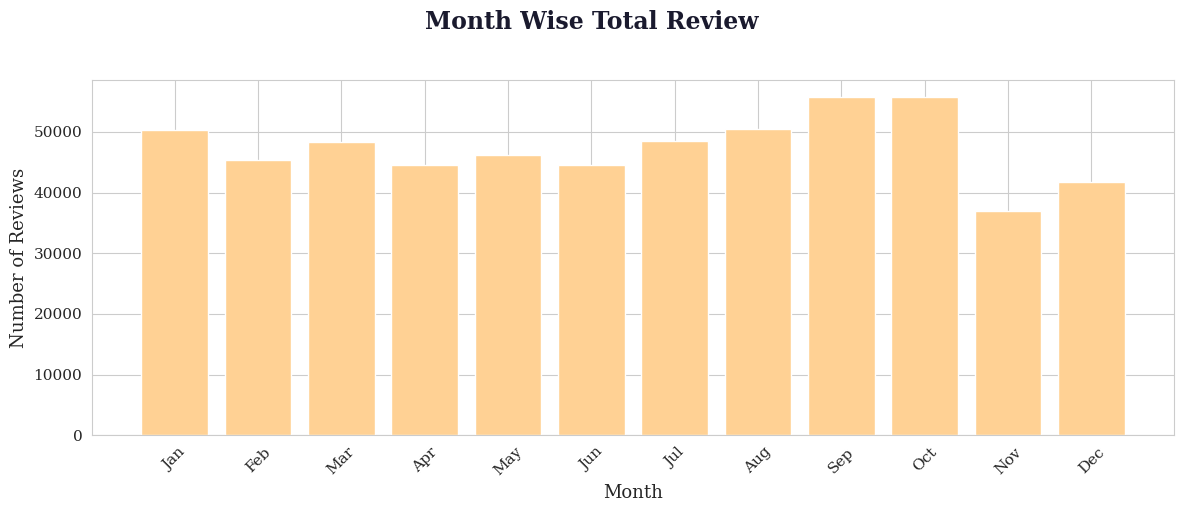

In [29]:
fig, axes = plt.subplots(figsize=(12, 5),layout="constrained")

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly = df.groupby('Month_Name').size().reindex(month_order).reset_index(name='Count')

axes.bar(range(12), monthly['Count'], color='#ffd194', edgecolor='white')
axes.set_xticks(range(12))
axes.set_xticklabels([m[:3] for m in month_order], rotation=45)
axes.set_xlabel('Month')
axes.set_ylabel('Number of Reviews')

plt.suptitle('Month Wise Total Review', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.4. Bivariate Analysis

#### ***Rating vs. Helpfulness Ratio***

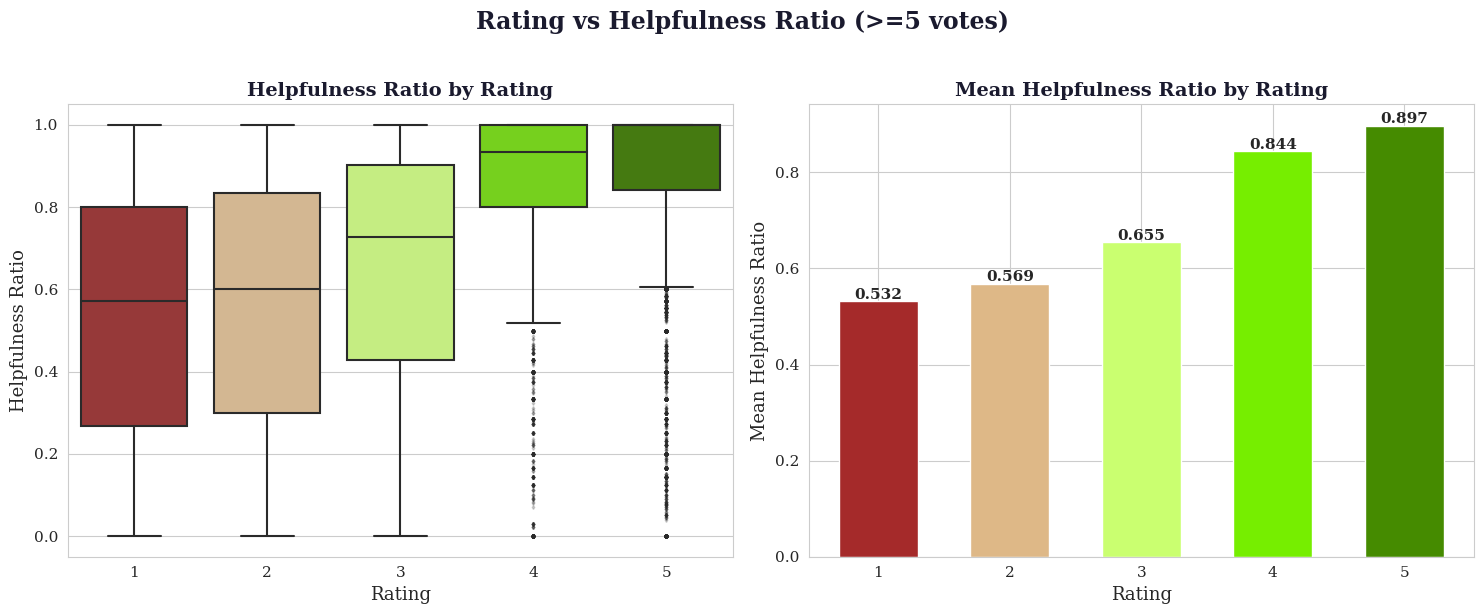

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
voted_df = df[df['HelpfulnessDenominator'] >= 5].copy()

sns.boxplot(x='Score', y='HelpfulnessRatio', data=voted_df, palette=colors_score, ax=axes[0],
            flierprops={'alpha': 0.2, 'markersize': 2})
axes[0].set_title('Helpfulness Ratio by Rating', fontsize=14, color=DARK, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Helpfulness Ratio')

mean_help = voted_df.groupby('Score')['HelpfulnessRatio'].mean()
axes[1].bar(mean_help.index, mean_help.values, color=colors_score, edgecolor='white', width=0.6)
for i, (idx, val) in enumerate(mean_help.items()):
    axes[1].text(idx, val + 0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Mean Helpfulness Ratio by Rating', fontsize=14, color=DARK, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Mean Helpfulness Ratio')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.suptitle('Rating vs Helpfulness Ratio (>=5 votes)', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### ***Review Length vs. Helpfulness***

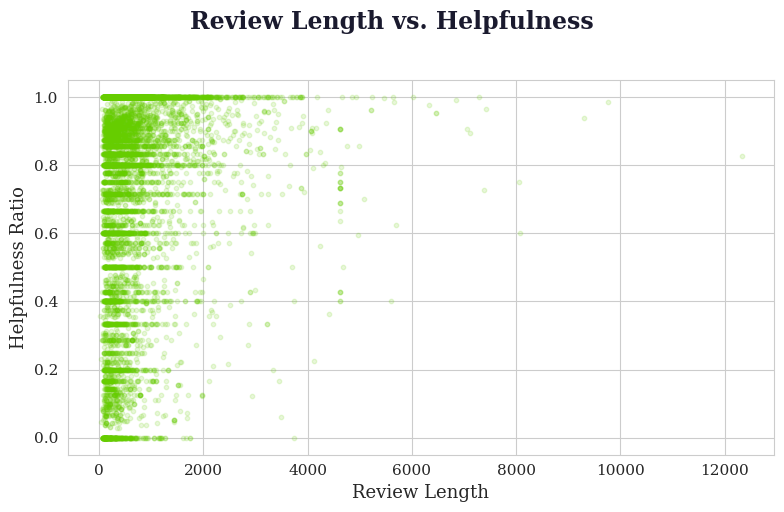

In [31]:
fig, axes = plt.subplots(figsize=(8, 5), layout='constrained')

sample = voted_df.sample(min(10000, len(voted_df)), random_state=42)
axes.scatter(sample['ReviewLength'], sample['HelpfulnessRatio'],
                alpha=0.15, s=10, color='#66cd00')
axes.set_xlabel('Review Length')
axes.set_ylabel('Helpfulness Ratio')

plt.suptitle('Review Length vs. Helpfulness', fontsize=17, color=DARK, fontweight='bold', y=1.02,x=0.5, ha='center')
plt.tight_layout()
plt.show()

#### ***Ratings vs Word Count***

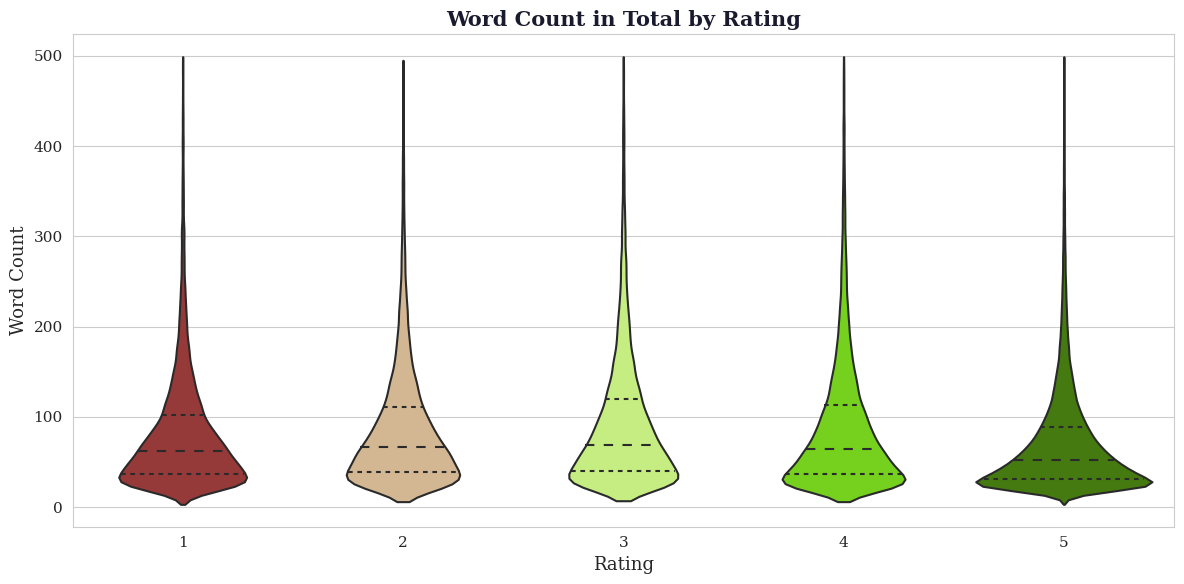

Mean Word Count by Rating:
Score
1    87.3
2    90.0
3    95.6
4    91.4
5    74.2


In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
df_viz = df[df['WordCount'] < 500]
sns.violinplot(x='Score', y='WordCount', data=df_viz, palette=colors_score,
               inner='quartile', cut=0, ax=ax)
ax.set_title('Word Count in Total by Rating', fontsize=15, color=DARK, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.show()

print("Mean Word Count by Rating:")
print(df.groupby('Score')['WordCount'].mean().round(1).to_string())

## 2.5. Correlation Analysis

#### ***Correlation Matrix***

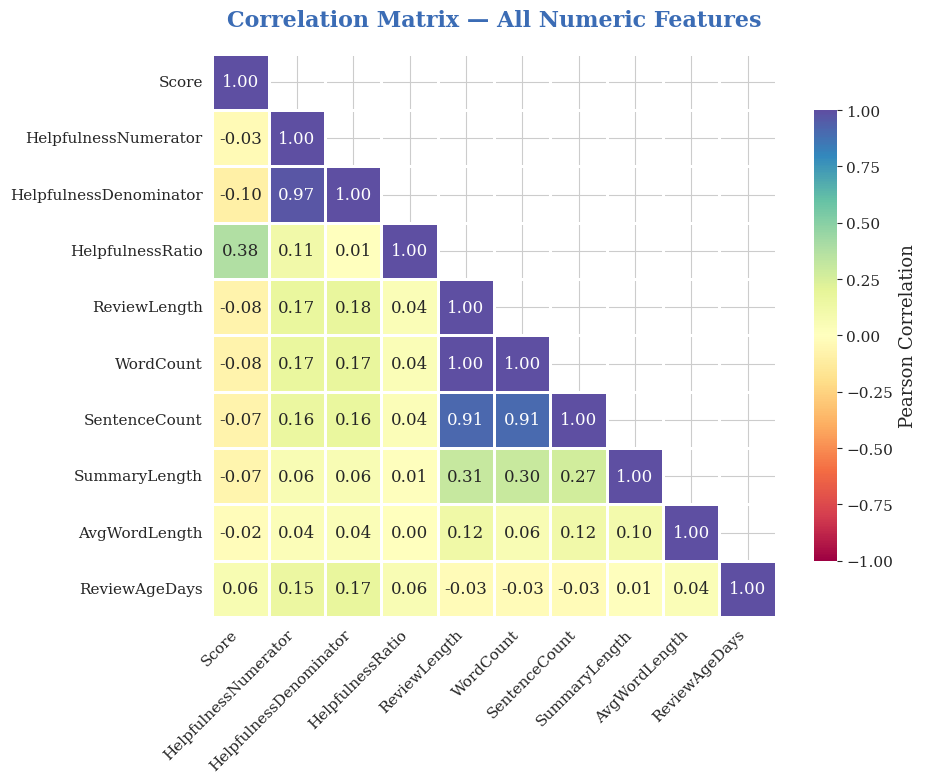

In [33]:
corr_cols = ['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
             'HelpfulnessRatio', 'ReviewLength', 'WordCount', 'SentenceCount',
             'SummaryLength', 'AvgWordLength', 'ReviewAgeDays']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='Spectral',
            center=0, square=True, linewidths=0.8, linecolor='white',
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'})
plt.title('Correlation Matrix — All Numeric Features',
          fontsize=16, color=NAVY, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
print("Correlations (|r| > 0.3):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            print(f"  {corr_matrix.columns[i]} × {corr_matrix.columns[j]}: r = {r:.3f}")

Correlations (|r| > 0.3):
  Score × HelpfulnessRatio: r = 0.377
  HelpfulnessNumerator × HelpfulnessDenominator: r = 0.975
  ReviewLength × WordCount: r = 0.995
  ReviewLength × SentenceCount: r = 0.907
  ReviewLength × SummaryLength: r = 0.307
  WordCount × SentenceCount: r = 0.905
  WordCount × SummaryLength: r = 0.303


## 2.6. Product & Reviewer Analysis

#### ***Top 10 Most Reviewed Products***

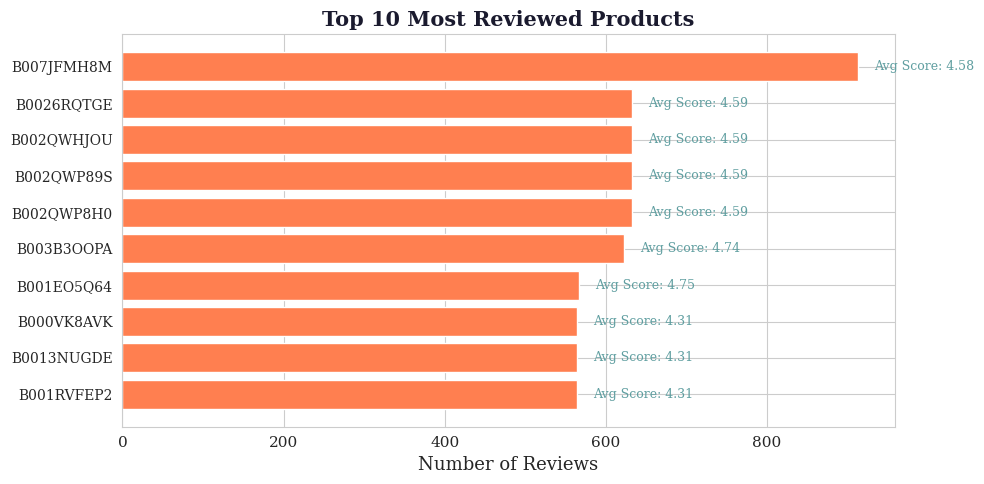

In [35]:
product_stats = df.groupby('ProductId').agg(
    ReviewCount=('Id', 'count'),
    AvgScore=('Score', 'mean'),
    ScoreStd=('Score', 'std'),
    AvgReviewLen=('ReviewLength', 'mean'),
    UniqueReviewers=('UserId', 'nunique')
).reset_index()
top_10 = product_stats.nlargest(10, 'ReviewCount')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(top_10)), top_10['ReviewCount'].values, color='#ff7f50', edgecolor='white')
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels(top_10['ProductId'].values, fontsize=10)
ax.invert_yaxis()
ax.set_title('Top 10 Most Reviewed Products', fontsize=15, color=DARK, fontweight='bold')
ax.set_xlabel('Number of Reviews')

for bar, score in zip(bars, top_10['AvgScore'].values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'Avg Score: {score:.2f}', va='center', fontsize=9, color='#5f9ea0')

plt.tight_layout()
plt.show()

#### ***Top 10 Most Active Reviewers***

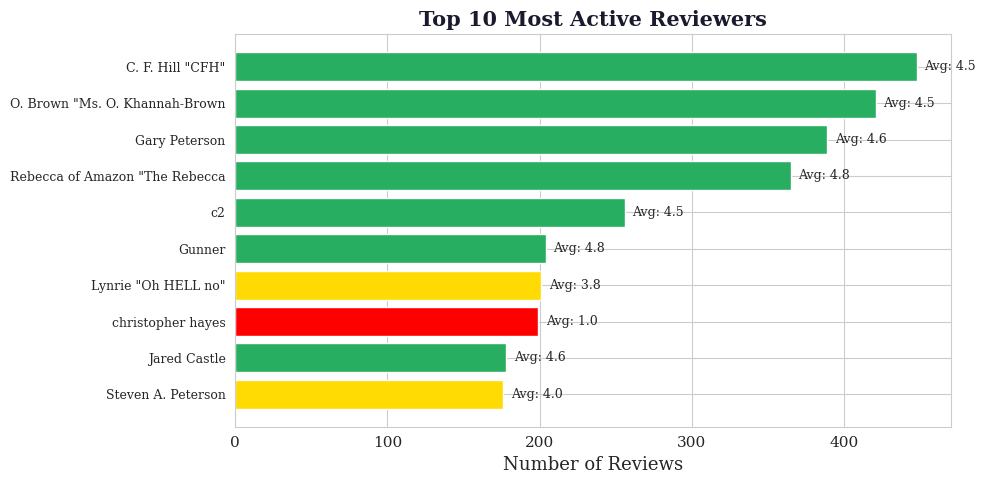

In [36]:
reviewer_stats = df.groupby('UserId').agg(
    ReviewCount=('Id', 'count'),
    AvgScore=('Score', 'mean'),
    ScoreStd=('Score', 'std'),
    AvgReviewLen=('ReviewLength', 'mean'),
    UniqueProducts=('ProductId', 'nunique'),
    TotalHelpfulVotes=('HelpfulnessNumerator', 'sum'),
    AvgHelpfulness=('HelpfulnessRatio', 'mean'),
).reset_index()

top_reviewers = reviewer_stats.nlargest(10, 'ReviewCount')
name_map = df.drop_duplicates(subset='UserId').set_index('UserId')['ProfileName']
top_reviewers = top_reviewers.copy()
top_reviewers['Name'] = top_reviewers['UserId'].map(name_map)
top_reviewers['Label'] = top_reviewers['Name'].str[:30]

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [RED if s < 3.5 else SUNFLOWER if s < 4.0 else GREEN for s in top_reviewers['AvgScore']]
bars = ax.barh(range(len(top_reviewers)), top_reviewers['ReviewCount'].values,
               color=colors_bar, edgecolor='white')
ax.set_yticks(range(len(top_reviewers)))
ax.set_yticklabels(top_reviewers['Label'].values, fontsize=9)
ax.invert_yaxis()
ax.set_title('Top 10 Most Active Reviewers', fontsize=15, color=DARK, fontweight='bold')
ax.set_xlabel('Number of Reviews')
for bar, row in zip(bars, top_reviewers.itertuples()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'Avg: {row.AvgScore:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2.7. Helpfulness Analysis

#### ***Helpfulness by Rating Category***

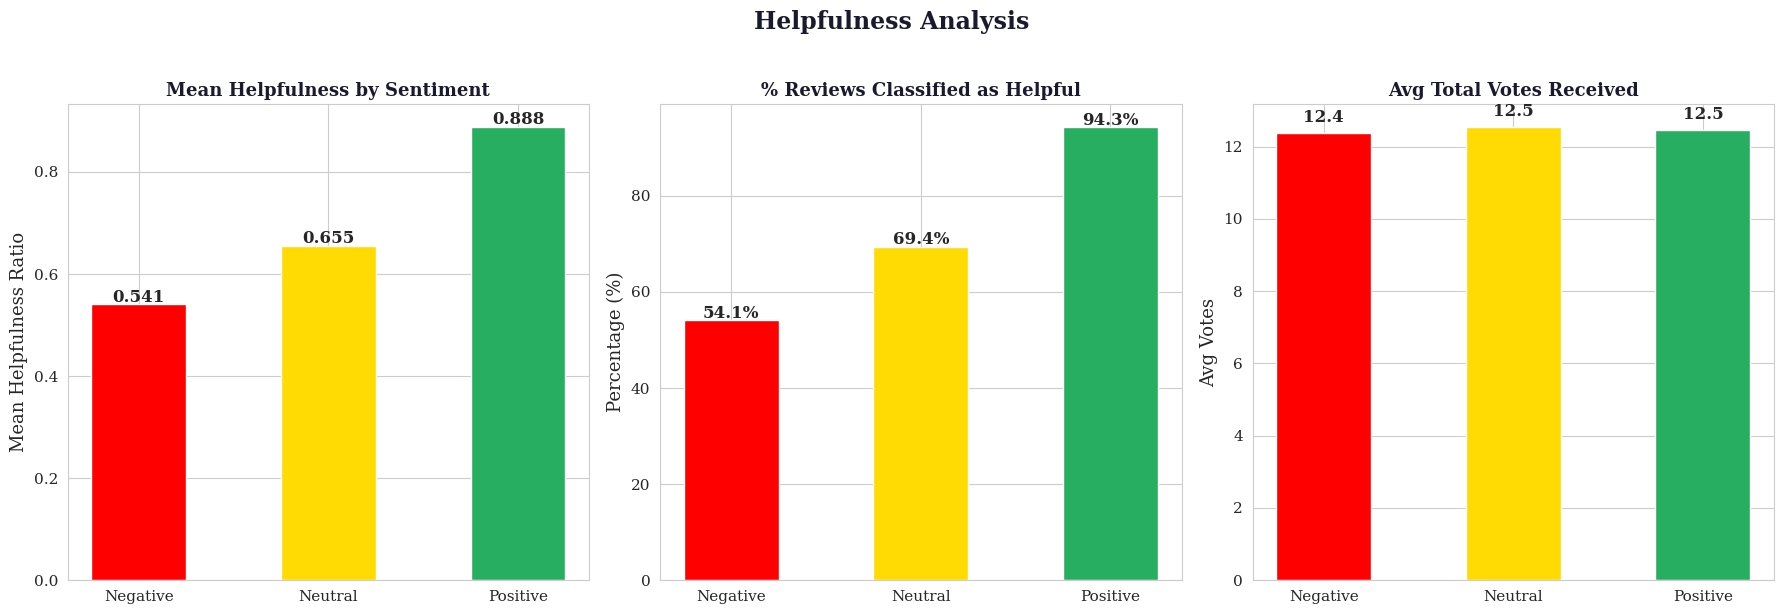

In [37]:
voted = df[df['HelpfulnessDenominator'] >= 5].copy()
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cat_help = voted.groupby('ScoreCategory')['HelpfulnessRatio'].mean().reindex(
    ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)'])
axes[0].bar(range(3), cat_help.values, color=[RED, SUNFLOWER,GREEN], edgecolor='white', width=0.5)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[0].set_title('Mean Helpfulness by Sentiment', fontsize=13, color=DARK, fontweight='bold')
axes[0].set_ylabel('Mean Helpfulness Ratio')
for i, v in enumerate(cat_help.values):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')

helpful_pct = voted.groupby('ScoreCategory')['IsHelpful'].mean().reindex(
    ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)']) * 100
axes[1].bar(range(3), helpful_pct.values, color=[RED, SUNFLOWER,GREEN], edgecolor='white', width=0.5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[1].set_title('% Reviews Classified as Helpful', fontsize=13, color=DARK, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(helpful_pct.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

avg_votes = voted.groupby('ScoreCategory')['HelpfulnessDenominator'].mean().reindex(
    ['Negative (1-2)', 'Neutral (3)', 'Positive (4-5)'])
axes[2].bar(range(3), avg_votes.values, color=[RED, SUNFLOWER,GREEN], edgecolor='white', width=0.5)
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[2].set_title('Avg Total Votes Received', fontsize=13, color=DARK, fontweight='bold')
axes[2].set_ylabel('Avg Votes')
for i, v in enumerate(avg_votes.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Helpfulness Analysis', fontsize=17, color=DARK, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.8. Text & Content Analysis

#### ***Summarization of Word Clouds***

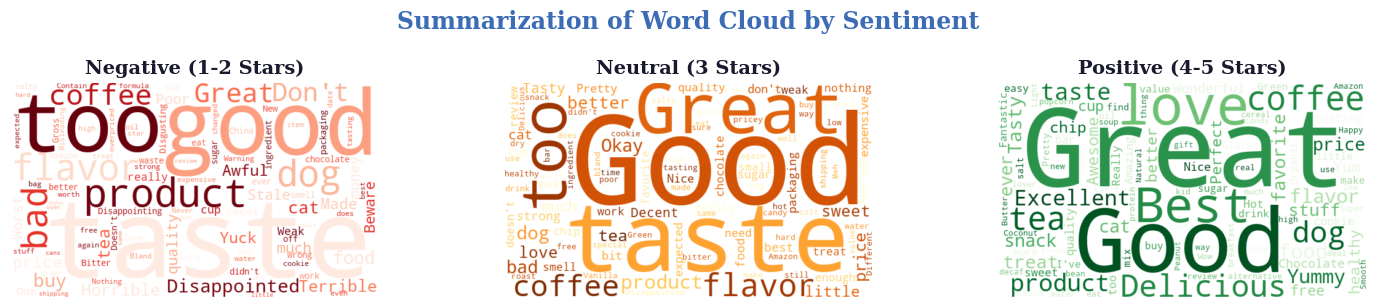

In [38]:
stop_words = {'the', 'a', 'an', 'is', 'it', 'in', 'to', 'of', 'and', 'for', 'on','that', 'this','with', 'was', 'as', 'are', 'be', 'at', 'or', 'from',
              'have', 'had', 'has', 'but', 'not', 'they', 'we', 'my', 'i', 'you','he', 'she', 'do', 'if', 'so', 'no', 'one', 'all', 'would', 'there',
              'their', 'what', 'about', 'which', 'when', 'can', 'more', 'been','will', 'its', 'than', 'just', 'very', 'also', 'some', 'me', 'up',
              'out', 'them', 'were', 'get', 'like', 'only', 'how', 'your', 'am','other', 'could', 'did', 'into', 'who', 'these', 'after', 'her',
              'him', 'his', 'our', 'any', 'may', 'br', 'by'}
from wordcloud import WordCloud
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, (label, score_range, cmap) in zip(axes, [
    ('Negative (1-2 Stars)', [1, 2], 'Reds'),
    ('Neutral (3 Stars)', [3], 'YlOrBr'),
    ('Positive (4-5 Stars)', [4, 5], 'Greens')
]):
    texts = df[df['Score'].isin(score_range)]['Summary'].astype(str)
    text_combined = ' '.join(texts.sample(min(30000, len(texts)), random_state=42))
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap=cmap, max_words=100, stopwords=stop_words,
                   min_word_length=3, collocations=False).generate(text_combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(label, fontsize=14, color=DARK, fontweight='bold')
    ax.axis('off')

plt.suptitle('Summarization of Word Cloud by Sentiment',
             fontsize=17, color=NAVY, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# **Natural Language Processing**

#### ***TF-IDF Vectorization***

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [40]:
X = df['Text']
y = df['ScoreCategory']

In [42]:
print("Splitting data into train and test sets")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Splitting data into train and test sets


In [43]:
print("Extracting TF-IDF features")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Extracting TF-IDF features


# **Machine Learning Approach**

## Random Forest Classifier

In [44]:
from sklearn.ensemble import RandomForestClassifier
print("Training Random Forest Classifier")
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)

Training Random Forest Classifier


RandomForestClassifier(n_jobs=-1, random_state=42)

In [45]:
print("Evaluation Results")
y_pred = rf_model.predict(X_test_tfidf)

Evaluation Results


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f_score = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("    RANDOM FOREST EVALUATION METRICS     ")
print(f"Accuracy:               {accuracy:.4f}")
print(f"Precision (Weighted):   {precision:.4f}")
print(f"Recall (Weighted):      {recall:.4f}")
print(f"F-Score (Weighted):     {f_score:.4f}")
print("---------------------------------------------")

    RANDOM FOREST EVALUATION METRICS     
Accuracy:               0.8974
Precision (Weighted):   0.9009
Recall (Weighted):      0.8974
F-Score (Weighted):     0.8852
---------------------------------------------


## XGBoost Classifier

In [49]:
!pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 187.9 kB/s eta 0:09:02
   ---------------------------------------- 0.0/101.7 MB 196.9 kB/s eta 0:08:37
   ---------------------------------------- 0.1/101.7 MB 280.5 kB/s eta 0:06:03
   ---------------------------------------- 0.1/101.7 MB 385.0 kB/s eta 0:04:24
   ---------------------------------------- 0.2/101.7 MB 458.0 kB/s eta 0:03:42
   ---------------------------------------- 0.2/101.7 MB 599.0 kB/s eta 0:02:50
   ----------------------------

In [53]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

label_encoder = LabelEncoder()
df['Target_Label'] = label_encoder.fit_transform(df['ScoreCategory'].astype(str))
num_classes = len(label_encoder.classes_)


In [57]:
X = df['Text']
y = df['Target_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [58]:
print("Training XGBoost Classifier")
if num_classes == 2:
    objective_setting = 'binary:logistic'
else:
    objective_setting = 'multi:softprob'

xgb_model = xgb.XGBClassifier(
    objective=objective_setting,
    num_class=num_classes if num_classes > 2 else None,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_tfidf, y_train)

Training XGBoost Classifier


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_class=3, ...)

In [59]:
y_pred_numeric = xgb_model.predict(X_test_tfidf)

y_test_text = label_encoder.inverse_transform(y_test)
y_pred_text = label_encoder.inverse_transform(y_pred_numeric)

In [60]:
accuracy = accuracy_score(y_test_text, y_pred_text)
precision = precision_score(y_test_text, y_pred_text, average='weighted', zero_division=0)
recall = recall_score(y_test_text, y_pred_text, average='weighted', zero_division=0)
f_score = f1_score(y_test_text, y_pred_text, average='weighted', zero_division=0)

print("       XGBOOST EVALUATION METRICS      ")
print(f"Accuracy:               {accuracy:.4f}")
print(f"Precision (Weighted):   {precision:.4f}")
print(f"Recall (Weighted):      {recall:.4f}")
print(f"F-Score (Weighted):     {f_score:.4f}")
print("----------------------------------------")

       XGBOOST EVALUATION METRICS      
Accuracy:               0.8361
Precision (Weighted):   0.8260
Recall (Weighted):      0.8361
F-Score (Weighted):     0.7968
----------------------------------------


## Naive Bayes Classifier

In [69]:
from sklearn.naive_bayes import MultinomialNB

label_encoder = LabelEncoder()
df['Target_Label'] = label_encoder.fit_transform(df['ScoreCategory'].astype(str))

X = df['Text']
y = df['Target_Label']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [71]:
print("Training Naive Bayes Classifier")
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

Training Naive Bayes Classifier


MultinomialNB()

In [72]:
y_pred_numeric = nb_model.predict(X_test_tfidf)

y_test_text = label_encoder.inverse_transform(y_test)
y_pred_text = label_encoder.inverse_transform(y_pred_numeric)

In [73]:
accuracy = accuracy_score(y_test_text, y_pred_text)
precision = precision_score(y_test_text, y_pred_text, average='weighted', zero_division=0)
recall = recall_score(y_test_text, y_pred_text, average='weighted', zero_division=0)
f_score = f1_score(y_test_text, y_pred_text, average='weighted', zero_division=0)

print("      NAIVE BAYES EVALUATION METRICS   ")
print(f"Accuracy:               {accuracy:.4f}")
print(f"Precision (Weighted):   {precision:.4f}")
print(f"Recall (Weighted):      {recall:.4f}")
print(f"F-Score (Weighted):     {f_score:.4f}")
print("--------------------------------------")

      NAIVE BAYES EVALUATION METRICS   
Accuracy:               0.8236
Precision (Weighted):   0.8059
Recall (Weighted):      0.8236
F-Score (Weighted):     0.7726
--------------------------------------
